# Exploratory Data Analysis

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import dask.dataframe as dd #pandas mejorado
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib import rc, rcParams
import matplotlib.gridspec as gridspec
from scipy.spatial import distance
from scipy.interpolate import make_interp_spline
import joblib

#astropy
from astropy.io import ascii, fits
from astropy.table import Table , vstack, hstack
from astropy import units as u
from astropy import cosmology
from astropy.cosmology import LambdaCDM, Planck18, Planck15
from astropy.coordinates import SkyCoord, Distance
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles
from astropy.stats import sigma_clip
from astropy.constants import c

#sklearn-ML
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KernelDensity
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestClassifier, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_validate, KFold, StratifiedKFold, learning_curve,cross_val_predict, GridSearchCV, cross_val_predict, cross_val_score, LeaveOneGroupOut
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve, classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, recall_score, f1_score, precision_score, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

## Dataset

In [3]:
#"d="/home/alonso_rodriguez/Desktop/Santa_Maria/10mo_semestre/TESIS/"
d='D:\\Santa María\\10mo semestre\\Tesis\\'
mock_id = '00'

fits_name = f'CHANCES_lowz_{mock_id}_with_true_subs.fits'
csv_name  = f'CHANCES_lowz_{mock_id}_with_true_subs_true_members.csv'

fits_path = os.path.join(d, 'Mocks', fits_name)
csv_path  = os.path.join(d, 'Mocks', csv_name)

data = fits.getdata(fits_path, 1)
df = pd.DataFrame(np.array(data).byteswap().view(data.dtype.newbyteorder('=')))
# df = df[df['redshift_S_1'] < 0.1].copy()
df_members = pd.read_csv(csv_path)

df['true_member'] = df['id'].isin(df_members['id']).astype(int)
df['mock_id'] = int(mock_id)

print(f"Total galaxias: {len(df)}")
print(f"Total miembros: {df['true_member'].sum()}")

Total galaxias: 935365
Total miembros: 1269


Identificación de columnas
             
Coordendas (15)
\
<strong>x, y, z -> </strong> coordenadas espaciales de la galaxia en el snapshot \
<strong>vx, vy, vz -></strong> velocidades \
<strong>RA, DEC -> </strong>ascensión recta y declinación \
<strong>g_lat, g_lon, ecl_lat, ecl_lon -> </strong>coordenadas galácticas y eclípticas \
<strong>redshift_R, redshift_S_1, redshift_S_2 -> </strong>diferentes estimaciones de redshift \
\
Halos (8)
\
<strong>Mvir -> </strong>masa virial del halo asociado \
<strong>Mpeak -> </strong>masa máxima histórica del halo \
<strong>Vmax -> </strong>velocidad máxima de rotación del subhalo \
<strong>Vmax_Mpeak -> </strong>Vmax en el momento de Mpeak \
<strong>id, desc_id, upid, ID_glist -> </strong>IDs \
\
Propiedades Físicas (11)
\
<strong>sm, sfr -> </strong>masa estelar y tasa de formación estelar 'verdadera'\
<strong>obs_sm, obs_sfr -> </strong>masa estelar y tasa de formación 'observacionales'\
<strong>obs_uv -> </strong>luminosidad UV observacional\
<strong>A_UV -> </strong>atenuación por polvo en UV\
<strong>icl -> </strong> intracluster light \
<strong>nH -> </strong>densidad de hidrógeno local\
<strong>ebv -> </strong>E(B-V) \
<strong>log10_sm, log10_sfr -> </strong>logaritmos de masa estelar y SFR\
\
Magnitudes (10)
\
<strong>K_mag_abs -> </strong>magnitud absoluta en banda K\
<strong>u_mag, g_mag, r_mag, i_mag, z_mag -> </strong>SDSS\
<strong>j_mag, h_mag, k_mag -> </strong>2MASS\
<strong>w1_mag -> </strong>WISE W1\
\
Subestructuras y clustering (8)
\
<strong>subs_labels_0 -> </strong>etiqueta de subestructura \
<strong>subs_probs_0 -> </strong>probabilidad de pertenencia a esa subestructura\
<strong>subs_cents_x_0, subs_cents_y_0, subs_cents_z_0 -> </strong>coordenadas del centro de la subestructura\
<strong>subs_meds_x_0, subs_meds_y_0, subs_meds_z_0 -> </strong>medianas de las posiciones de la subestructura\
\
Distancias (2)
\
<strong>dL -> </strong>distancia luminosa\
<strong>distance_match -> </strong> ?


In [4]:
OMegaM = 0.3089
OmegaL = 0.6911 
h = 0.6774
cosmo = LambdaCDM(H0 = h*100, Om0 = OMegaM, Ode0 = OmegaL)
c_kms = c.to(u.km / u.s).value

cluster_catalogue = pd.read_csv(os.path.join(d, 'Mock-clusters_True_information.csv'))
target_cl = cluster_catalogue[cluster_catalogue['Cluster'] == int(mock_id)].iloc[0]

# Cluster properties
RA_cl, DEC_cl = target_cl['RA'], target_cl['Dec']
z_cl = target_cl['redshift']
R200_mpc = target_cl['R_200_mpc']

cg = SkyCoord(df['RA'].values * u.deg, df['DEC'].values * u.deg, frame = 'icrs')   # gal coordinates
cc = SkyCoord(RA_cl * u.deg, DEC_cl * u.deg, frame = 'icrs')                                # cluster coords

# Angular separation
sep_deg = cg.separation(cc).deg

#  convert to Mpc
scale_kpc_arcmin = cosmo.kpc_proper_per_arcmin(z_cl).value  
sep_mpc = (scale_kpc_arcmin * sep_deg * 60) / 1000

df['R_proj_mpc'] = sep_mpc
df['V_pec_kms'] = c_kms * (df['redshift_S_1'] - z_cl) / (1 + z_cl)  # V.pec

#Densidad local
coords_rad = np.deg2rad(df[['DEC', 'RA']].values)

# Nearest Neighbors 
nbrs = NearestNeighbors(n_neighbors = 11, metric = 'haversine', n_jobs = -1).fit(coords_rad)
dist_rad, _ = nbrs.kneighbors(coords_rad)

theta_10_rad = dist_rad[:, -1]                        # distance to 10th neighbor in rad
da_mpc = cosmo.angular_diameter_distance(df['redshift_S_1'].values).value
r10 = theta_10_rad * da_mpc                        # distance to 10th neighbor in Mpc

# Surface density [gal / Mpc^2]
df['local_density'] = 10 / (np.pi * r10**2)
df['log_density'] = np.log10(df['local_density'])

In [5]:
x, y, z = df['x'],df['y'],df['z']
r = np.sqrt(x**2 + y**2 + z**2)

print('N° galaxies: ', len(df))

N° galaxies:  935365


In [6]:
# dict = {column: list}
cols_dict = {col: df[col].tolist() for col in df.columns}

df = pd.DataFrame(cols_dict)
df['r'] = r
df['g_r'] = df['g_mag'] - df['r_mag']

In [7]:
df.columns

Index(['x', 'y', 'z', 'Mvir', 'icl', 'id', 'obs_sfr', 'obs_sm', 'obs_uv',
       'sfr', 'sm', 'upid', 'A_UV', 'Mpeak', 'Vmax_Mpeak', 'desc_id', 'lvmp',
       'vmax', 'vx', 'vy', 'vz', 'RA', 'DEC', 'g_lat', 'g_lon', 'ecl_lat',
       'ecl_lon', 'redshift_R', 'redshift_S_1', 'dL', 'nH', 'ebv',
       'redshift_S_2', 'log10_sm', 'log10_sfr', 'K_mag_abs', 'u_mag', 'g_mag',
       'r_mag', 'i_mag', 'z_mag', 'j_mag', 'h_mag', 'k_mag', 'w1_mag',
       'distance_match', 'ID_glist', 'subs_labels_0', 'subs_probs_0',
       'subs_cents_x_0', 'subs_cents_y_0', 'subs_cents_z_0', 'subs_meds_x_0',
       'subs_meds_y_0', 'subs_meds_z_0', 'true_member', 'mock_id',
       'R_proj_mpc', 'V_pec_kms', 'local_density', 'log_density', 'r', 'g_r'],
      dtype='object')

In [8]:
print('id:', df['id'].nunique())
print('upid:', df['upid'].nunique())

id: 935365
upid: 121142


In [9]:
print(df['subs_probs_0'].value_counts())

subs_probs_0
0.000000    334085
1.000000    297902
0.976739         7
0.334206         6
0.441723         6
             ...  
0.145814         1
0.797851         1
0.825601         1
0.115594         1
0.109868         1
Name: count, Length: 275427, dtype: int64


In [10]:
df.iloc[:, :20].describe()

,x,y,z,Mvir,icl,id,obs_sfr,obs_sm,obs_uv,sfr,sm,upid,A_UV,Mpeak,Vmax_Mpeak,desc_id,lvmp,vmax,vx,vy
count,935365.000000,935365.000000,935365.000000,9.353650e+05,9.353650e+05,9.353650e+05,935365.000000,9.353650e+05,935365.000000,935365.000000,9.353650e+05,9.353650e+05,935365.000000,9.353650e+05,935365.000000,9.353650e+05,725684.000000,935365.000000,935365.000000,935365.000000
mean,-1733.057261,341.425702,899.180794,3.481164e+11,3.402937e+08,1.429905e+15,1.202924,7.299884e+09,-12.650216,0.939862,7.155829e+09,3.713399e+13,0.164668,4.122938e+11,114.254446,1.482057e+15,2.024239,103.813516,2.637332,50.222247
std,467.329117,100.508933,245.705735,2.894620e+12,6.763051e+09,3.875621e+15,3.462728,2.147829e+10,7.678668,2.673121,2.039541e+10,5.701028e+13,0.215054,2.997043e+12,53.020588,4.022485e+15,0.145274,51.159955,358.601763,342.996337
min,-2411.892578,2.737895,7.453470,7.000184e+09,-2.924282e+12,4.284666e+13,0.000000,3.015234e+07,-21.883400,0.000000,1.000001e+08,-1.000000e+00,0.000000,8.502000e+09,44.430000,-1.000000e+00,1.647676,30.410000,-2859.030029,-2964.489990
25%,-2133.166504,271.860077,740.413330,4.480000e+10,1.311639e+05,7.105601e+13,0.057988,2.180359e+08,-17.938894,0.046168,2.181637e+08,-1.000000e+00,0.000000,6.573000e+10,84.480003,7.105601e+13,1.921322,76.500000,-219.607834,-166.669998
50%,-1818.509033,351.095367,939.173279,8.143000e+10,3.857983e+06,1.114974e+14,0.165829,6.165222e+08,-16.471704,0.131262,6.153423e+08,-1.000000e+00,0.093052,1.063000e+11,98.089996,1.114974e+14,1.986548,89.599998,13.280000,56.139999
75%,-1433.598999,417.299957,1100.383911,1.743000e+11,2.193607e+07,1.657171e+14,0.707401,3.508850e+09,0.000000,0.560427,3.516567e+09,7.102165e+13,0.219143,2.220000e+11,124.389999,1.657171e+14,2.090082,113.599998,237.470001,266.233215
max,-14.201416,554.248596,1309.049316,5.635000e+14,1.447066e+12,3.524739e+16,212.628036,1.319299e+12,0.000000,158.607101,1.209145e+12,2.611341e+14,2.249914,5.635000e+14,1424.229980,3.620623e+16,3.153580,1424.229980,2792.879883,3008.570068


In [11]:
df.iloc[:,20:40].describe()

,vz,RA,DEC,g_lat,g_lon,ecl_lat,ecl_lon,redshift_R,redshift_S_1,dL,nH,ebv,redshift_S_2,log10_sm,log10_sfr,K_mag_abs,u_mag,g_mag,r_mag,i_mag
count,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000,9.353650e+05,9.353650e+05,935365.000000,935365.000000,935365.000000,9.353650e+05,935365.000000,824117.000000,935365.000000,935365.000000,928246.000000
mean,-164.306094,348.865192,-26.971278,-68.632622,27.815429,-20.344799,338.842388,0.518476,0.518246,9.547519e+27,1.213761e+20,0.033887,0.518246,9.004492,-inf,-19.511017,23.939398,23.484490,22.567178,22.135986
std,395.199721,1.187310,1.171481,1.053596,3.233879,1.138156,1.166743,0.155961,0.155762,3.295972e+27,1.932410e+19,0.011293,0.155762,0.814273,NaN,1.584618,1.120979,0.983768,0.972140,1.108547
min,-3591.760010,346.854675,-29.070820,-70.605307,21.968831,-23.021685,336.185382,0.003680,0.003435,5.039335e+25,8.847431e+19,0.020829,0.003435,7.479321,-inf,-25.808025,14.284905,13.089270,12.731485,12.678092
25%,-420.380005,347.830109,-27.957241,-69.526808,25.101976,-21.246955,337.930440,0.409618,0.409274,7.105068e+27,1.064367e+20,0.026335,0.409274,8.338528,-1.236665e+00,-20.552978,23.318073,23.041434,22.198957,21.640507
50%,-153.405289,348.848267,-26.931202,-68.621004,27.926333,-20.309655,338.817812,0.540225,0.539613,9.881834e+27,1.180451e+20,0.029523,0.539613,8.789948,-7.803385e-01,-19.120385,23.863351,23.647384,22.829252,22.327623
75%,101.629997,349.880981,-25.978676,-67.718355,30.542404,-19.438220,339.766697,0.654363,0.654557,1.246108e+28,1.325492e+20,0.037271,0.654557,9.545165,-1.503342e-01,-18.258325,24.483804,24.138285,23.214781,22.819273
max,2814.919922,350.951355,-24.974098,-66.583241,34.237776,-17.785168,341.540316,0.739516,0.742281,1.446624e+28,2.351793e+20,0.094579,0.742281,12.120343,2.327621e+00,-15.822477,35.639552,24.999998,24.901355,33.129324


In [12]:
df.iloc[:,40:].describe()

,z_mag,j_mag,h_mag,k_mag,w1_mag,distance_match,ID_glist,subs_labels_0,subs_probs_0,subs_cents_x_0,...,subs_meds_y_0,subs_meds_z_0,true_member,mock_id,R_proj_mpc,V_pec_kms,local_density,log_density,r,g_r
count,935365.000000,123279.000000,115561.000000,935365.000000,112663.000000,9.353650e+05,9.353650e+05,935365.00000,935365.000000,935365.000000,...,935365.000000,935365.000000,935365.000000,935365.0,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000,935365.000000
mean,21.908564,20.934349,20.691790,21.817873,21.146329,6.926852e-04,5.221691e+06,17091.97512,0.514277,-1115.283469,...,219.340572,578.027342,0.001357,0.0,6.166468,130446.467360,211.821328,2.185297,1982.817993,0.917312
std,1.106824,1.748403,1.820938,1.669427,1.948141,3.246704e-03,2.686999e+06,17079.00740,0.438643,910.669759,...,182.894307,474.200646,0.036808,0.0,2.322382,44139.680013,786.390085,0.295584,534.549011,0.440557
min,12.319981,11.995824,11.823842,11.931495,12.706226,2.414056e-07,4.610000e+02,-1.00000,0.000000,-2411.731554,...,-1.000000,-1.000000,0.000000,0.0,0.000000,-15440.285909,17.687745,1.247672,16.270540,-2.719622
25%,21.390333,19.850950,19.540556,20.705853,19.872561,1.341006e-04,3.240318e+06,-1.00000,0.000000,-1958.497005,...,-1.000000,-1.000000,0.000000,0.0,4.473712,99565.896836,96.319737,1.983715,1633.489136,0.601951
50%,22.187342,21.198277,20.901586,22.177920,21.080018,2.522437e-04,5.260142e+06,13224.00000,0.569981,-1377.041858,...,261.194275,711.678467,0.000000,0.0,6.417098,136501.345690,142.712416,2.154462,2079.231201,0.843652
75%,22.668815,22.110722,21.871916,23.142604,22.326727,5.028519e-04,7.461469e+06,32925.00000,1.000000,-1.000000,...,379.843536,1021.346313,0.000000,0.0,7.903077,169073.863115,222.757093,2.347832,2441.037109,1.173138
max,24.850961,33.938742,32.750439,25.370185,35.732581,1.235194e-01,1.266405e+07,49119.00000,1.000000,-1.000000,...,552.825500,1308.010620,1.000000,0.0,11.482345,193932.989430,524430.639625,5.719688,2695.110596,4.817032


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935365 entries, 0 to 935364
Data columns (total 63 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   x               935365 non-null  float64
 1   y               935365 non-null  float64
 2   z               935365 non-null  float64
 3   Mvir            935365 non-null  float64
 4   icl             935365 non-null  float64
 5   id              935365 non-null  int64  
 6   obs_sfr         935365 non-null  float64
 7   obs_sm          935365 non-null  float64
 8   obs_uv          935365 non-null  float64
 9   sfr             935365 non-null  float64
 10  sm              935365 non-null  float64
 11  upid            935365 non-null  int64  
 12  A_UV            935365 non-null  float64
 13  Mpeak           935365 non-null  float64
 14  Vmax_Mpeak      935365 non-null  float64
 15  desc_id         935365 non-null  int64  
 16  lvmp            725684 non-null  float64
 17  vmax      

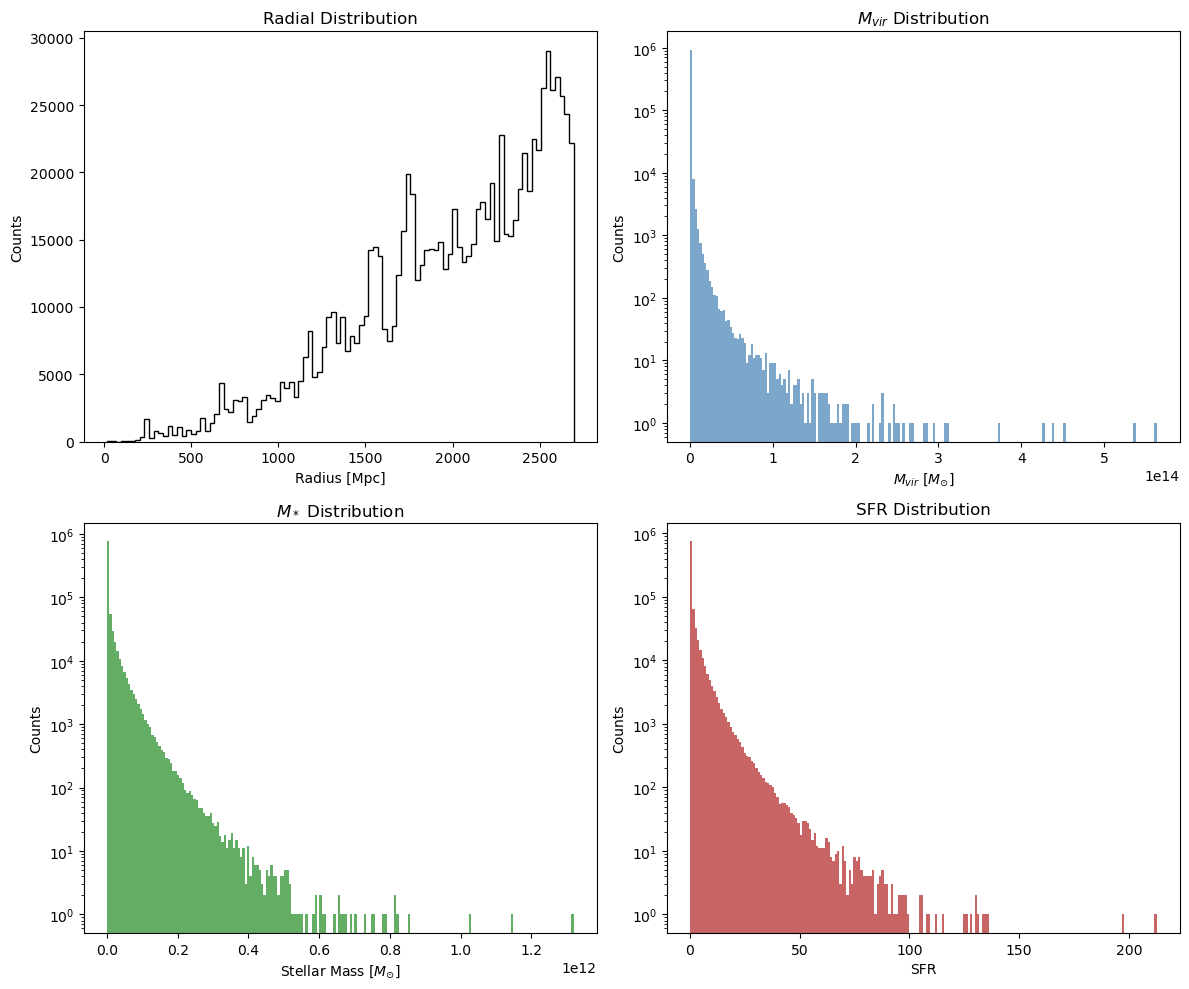

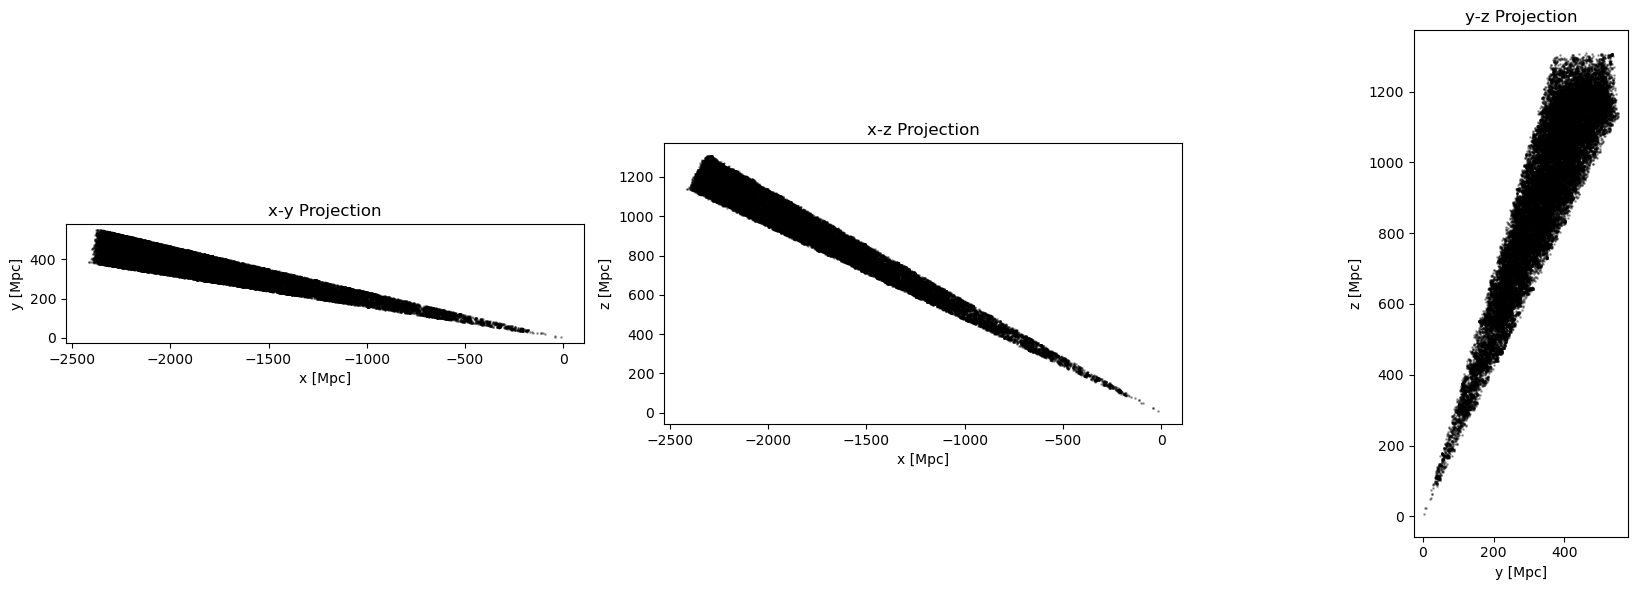

C:\Users\alonx\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


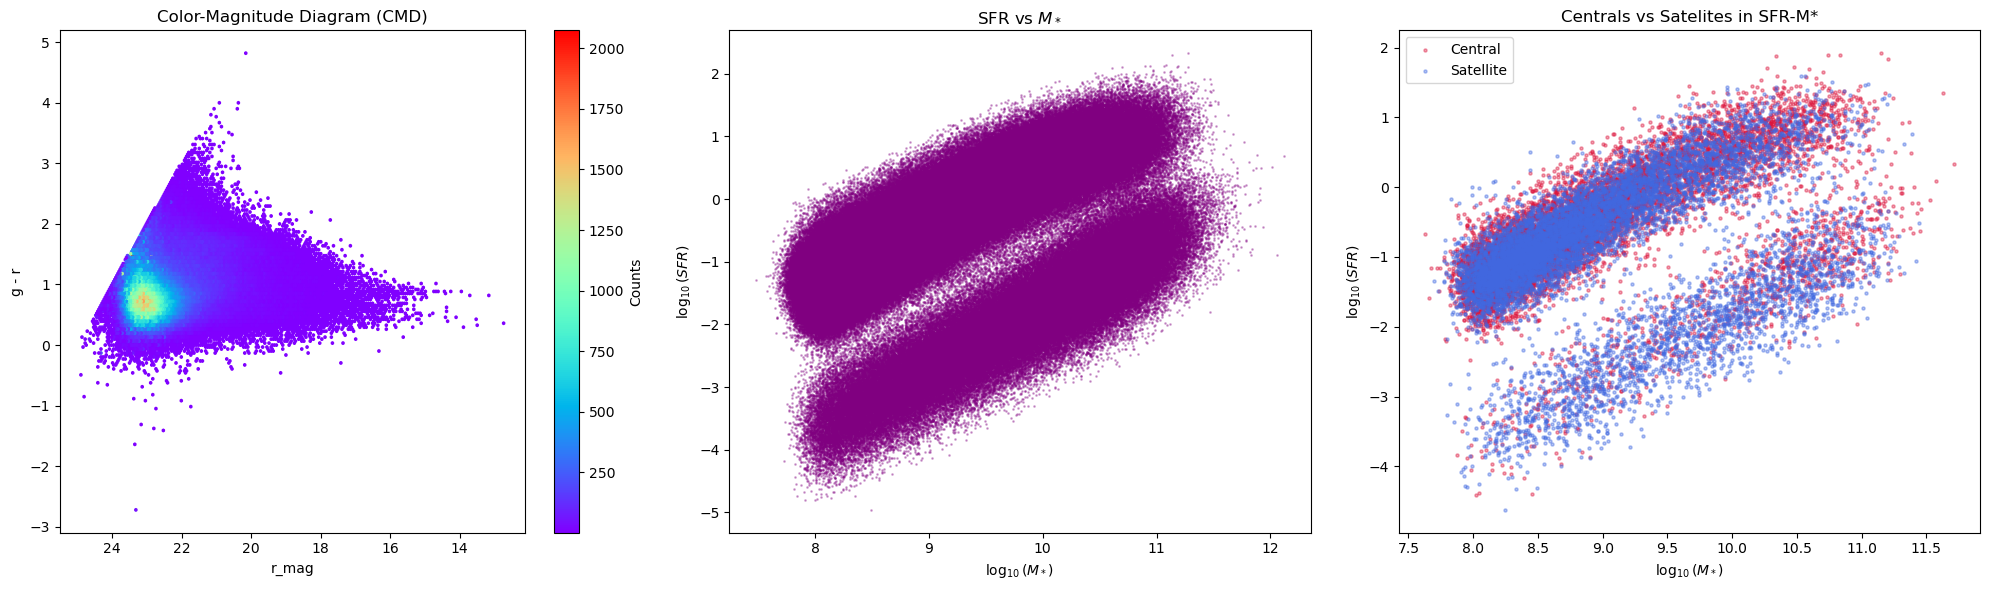

In [14]:
fig, axs = plt.subplots(2, 2, figsize = (12, 10))
axs = axs.flatten()

axs[0].hist(df['r'], bins = 100, histtype = 'step', color = 'k')     # Radial Distribution
axs[0].set_xlabel('Radius [Mpc]')
axs[0].set_ylabel('Counts')
axs[0].set_title('Radial Distribution')

axs[1].hist(df['Mvir'], bins = 200, color='steelblue', alpha = 0.7)    #  Mvir Distribution
axs[1].set_yscale('log')
axs[1].set_xlabel(r'$M_{vir}$ [$M_{\odot}$]')
axs[1].set_ylabel('Counts')
axs[1].set_title(r'$M_{vir}$ Distribution')

axs[2].hist(df['obs_sm'], bins = 200, color = 'forestgreen', alpha = 0.7)   # Stellar Mass Distribution
axs[2].set_yscale('log')
axs[2].set_xlabel(r'Stellar Mass [$M_{\odot}$]')
axs[2].set_ylabel('Counts')
axs[2].set_title(r'$M_*$ Distribution')

axs[3].hist(df['obs_sfr'], bins = 200, color = 'firebrick', alpha = 0.7)   # SFR Distribution
axs[3].set_yscale('log')
axs[3].set_xlabel('SFR')
axs[3].set_ylabel('Counts')
axs[3].set_title('SFR Distribution')

plt.tight_layout()
plt.show()

# Positions
sample = df.sample(frac = 0.05, random_state = 1)       
fig, axs = plt.subplots(1, 3, figsize = (18, 6))

axs[0].scatter(sample['x'], sample['y'], s = 1, alpha = 0.3, color = 'k')
axs[0].set_xlabel('x [Mpc]')
axs[0].set_ylabel('y [Mpc]')
axs[0].set_title('x-y Projection')
axs[0].set_aspect('equal')

axs[1].scatter(sample['x'], sample['z'], s = 1, alpha = 0.3, color = 'k')
axs[1].set_xlabel('x [Mpc]')
axs[1].set_ylabel('z [Mpc]')
axs[1].set_title('x-z Projection')
axs[1].set_aspect('equal')

axs[2].scatter(sample['y'], sample['z'], s = 1, alpha = 0.3, color = 'k')
axs[2].set_xlabel('y [Mpc]')
axs[2].set_ylabel('z [Mpc]')
axs[2].set_title('y-z Projection')
axs[2].set_aspect('equal')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize = (20, 6))

# CMD (Hexbin)
hb = axs[0].hexbin(df['r_mag'], df['g_r'], gridsize = 200, cmap = 'rainbow', mincnt = 1)
axs[0].invert_xaxis()
axs[0].set_xlabel('r_mag')
axs[0].set_ylabel('g - r')
axs[0].set_title('Color-Magnitude Diagram (CMD)')
cb = fig.colorbar(hb, ax = axs[0], label = 'Counts')

# SFR vs M*
axs[1].scatter(np.log10(df['obs_sm']), np.log10(df['obs_sfr']), s = 1, alpha = 0.3, color = 'purple')
axs[1].set_xlabel(r'$\log_{10}(M_*)$')
axs[1].set_ylabel(r'$\log_{10}(SFR)$')
axs[1].set_title(r'SFR vs $M_*$')

# Centrals vs Satellites
centrales = df[df['upid'] == -1].sample(n = min(10000, len(df[df['upid'] == -1])))
satelites = df[df['upid'] != -1].sample(n = min(10000, len(df[df['upid'] != -1])))

axs[2].scatter(np.log10(centrales['obs_sm']), np.log10(centrales['obs_sfr']), s = 5, alpha = 0.4, label = 'Central', color = 'crimson')
axs[2].scatter(np.log10(satelites['obs_sm']), np.log10(satelites['obs_sfr']), s = 5, alpha = 0.4, label = 'Satellite', color = 'royalblue')

axs[2].set_xlabel(r'$\log_{10}(M_*)$')
axs[2].set_ylabel(r'$\log_{10}(SFR)$')
axs[2].set_title('Centrals vs Satelites in SFR-M*')
axs[2].legend()

plt.tight_layout()
plt.show()

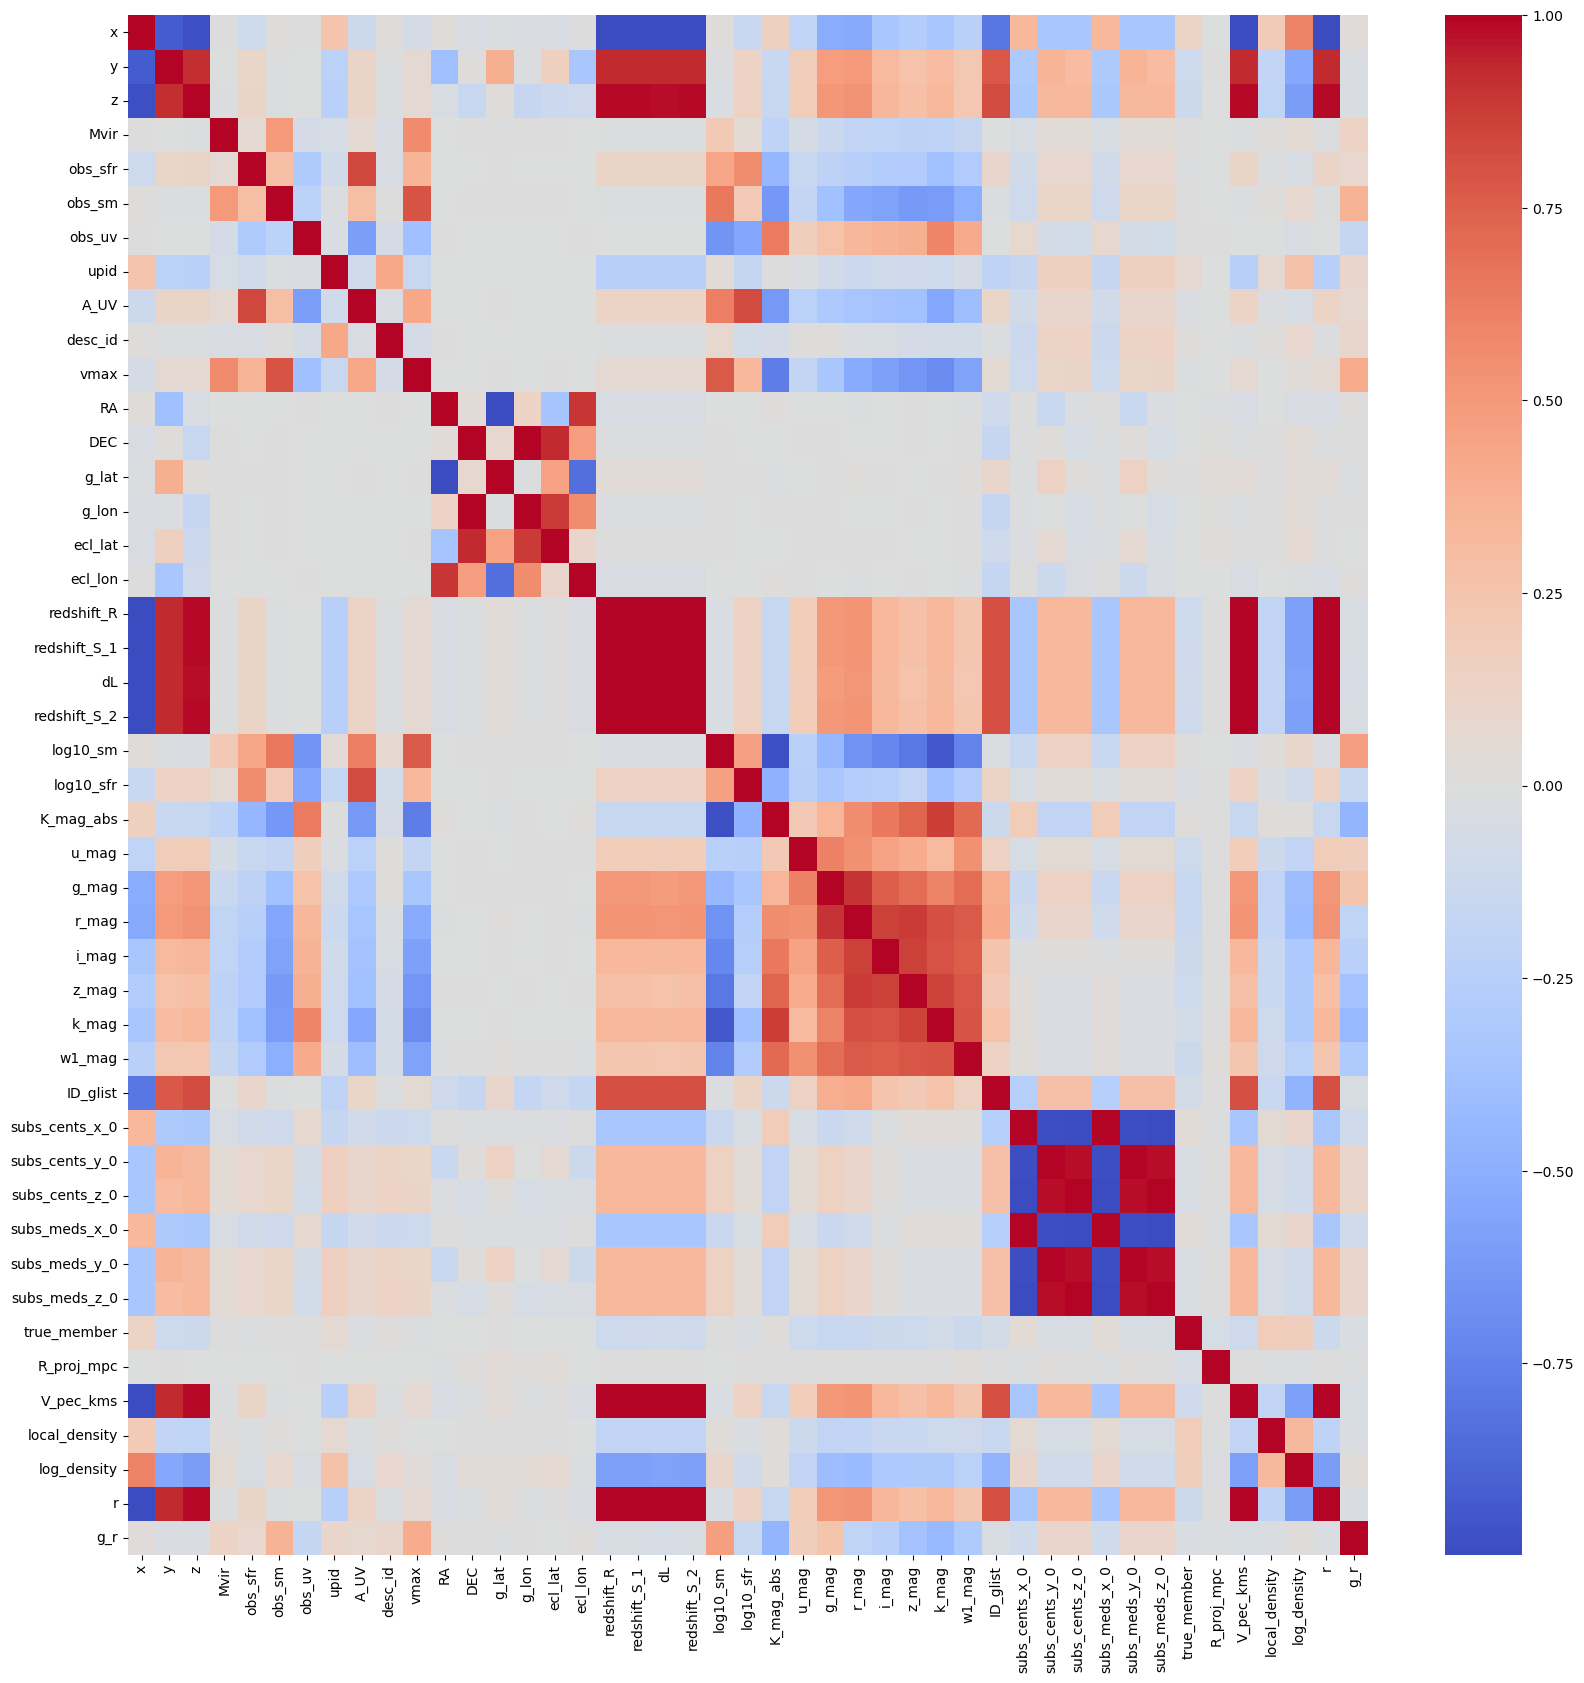

In [20]:
corrected = df.drop(columns = {'id','icl','vy','vx','vz','nH','lvmp','ebv','distance_match','subs_labels_0','subs_probs_0','sm','sfr', 'Vmax_Mpeak','Mpeak','h_mag','j_mag', 'mock_id'})
corr_mtx = corrected.corr()

plt.figure(figsize = (20, 20))
sns.heatmap(corr_mtx, annot = False, cmap = 'coolwarm', cbar = True)
plt.show()

In [16]:
#######################    RA & DEC    #########################

In [17]:
df[['RA', 'DEC']].describe()

,RA,DEC
count,935365.000000,935365.000000
mean,348.865192,-26.971278
std,1.187310,1.171481
min,346.854675,-29.070820
25%,347.830109,-27.957241
50%,348.848267,-26.931202
75%,349.880981,-25.978676
max,350.951355,-24.974098


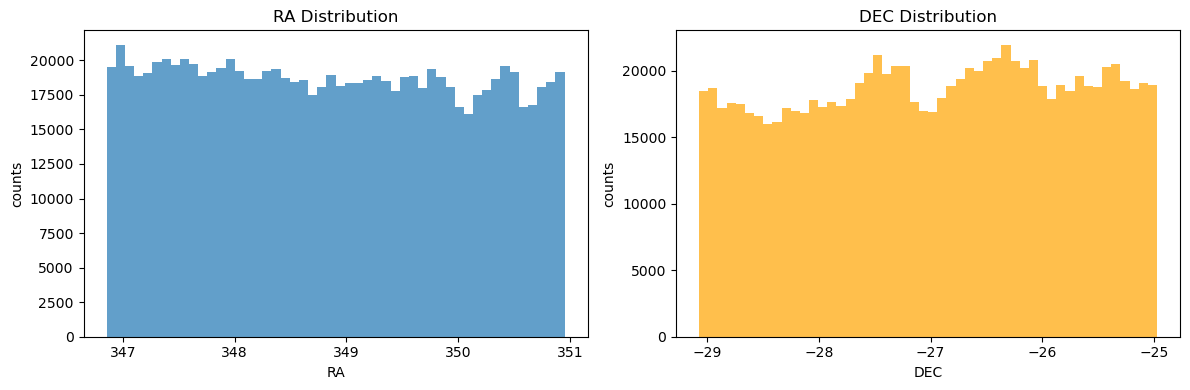

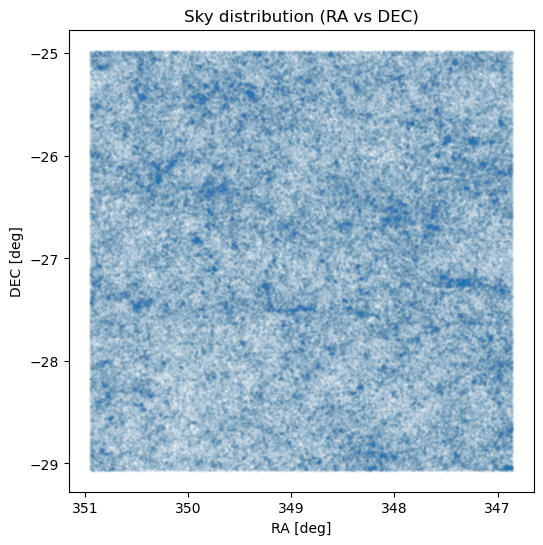

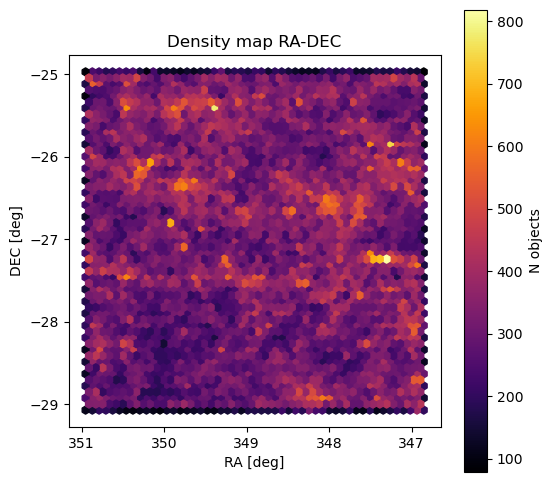

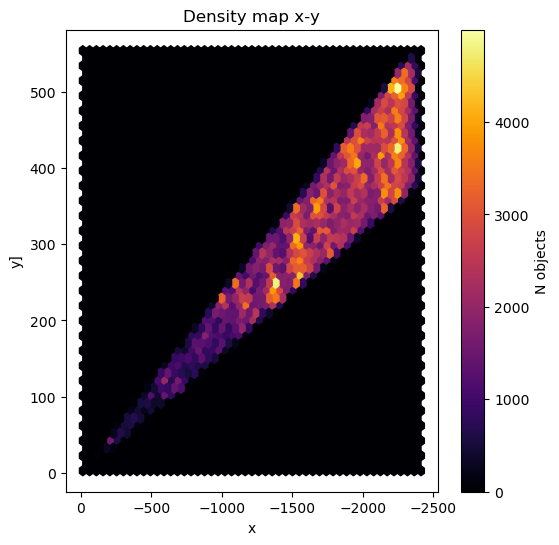

In [22]:
fig, axs = plt.subplots(1, 2, figsize = (12, 4))

axs[0].hist(df['RA'], bins=50, alpha=0.7)
axs[0].set_title('RA Distribution')
axs[0].set_xlabel('RA')
axs[0].set_ylabel('counts')

axs[1].hist(df['DEC'], bins=50, alpha=0.7, color='orange')
axs[1].set_title('DEC Distribution')
axs[1].set_xlabel('DEC')
axs[1].set_ylabel('counts')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df['RA'], df['DEC'], s=0.001, alpha=0.5)
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Sky distribution (RA vs DEC)')
plt.gca().invert_xaxis()
plt.show()


plt.figure(figsize=(6,6))
plt.hexbin(df['RA'], df['DEC'], gridsize=50, cmap='inferno')
plt.colorbar(label='N objects')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Density map RA-DEC')
plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()
plt.show()


plt.figure(figsize=(6,6))
plt.hexbin(df['x'], df['y'], gridsize=50, cmap='inferno')
plt.colorbar(label='N objects')
plt.xlabel('x')
plt.ylabel('y]')
plt.title('Density map x-y')
plt.gca().invert_xaxis()
plt.show()

In [19]:
df[['RA', 'DEC', 'x', 'y', 'z']].corr()

,RA,DEC,x,y,z
RA,1.000000,0.035280,0.016710,-0.386220,-0.038639
DEC,0.035280,1.000000,-0.031620,0.014403,-0.154429
x,0.016710,-0.031620,1.000000,-0.923194,-0.981246
y,-0.386220,0.014403,-0.923194,1.000000,0.914972
z,-0.038639,-0.154429,-0.981246,0.914972,1.000000


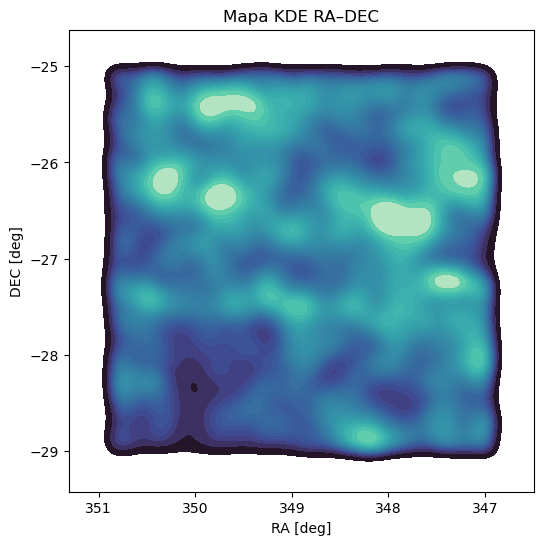

In [80]:
# kde
plt.figure(figsize=(6,6))
sns.kdeplot(x=df['RA'], y=df['DEC'], fill=True, cmap='mako', levels=30, thresh=0.05)
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('KDE RA–DEC map')
plt.gca().invert_xaxis()
plt.show()

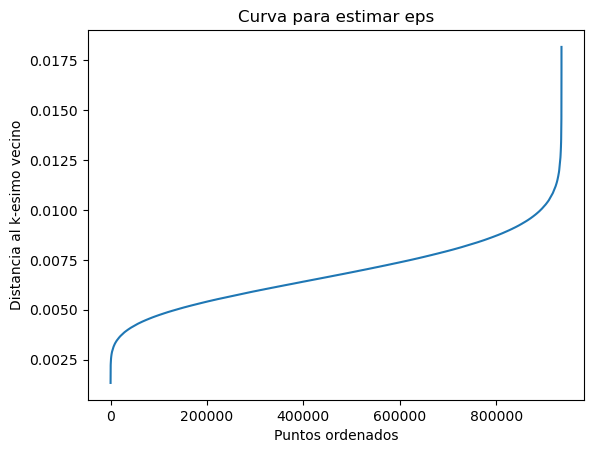

In [198]:
# DBSCAN identifies groups base on density (clustering) 
# need eps (radius to search neighbors) & the minimum number of instances to form a group

coords = np.vstack([df['RA'], df['DEC']]).T
#coords_scaled = StandardScaler().fit_transform(coords)

### k distance plot to estimate eps ###
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(coords)
distances, indices = neighbors_fit.kneighbors(coords)
distances = np.sort(distances[:,9])
plt.plot(distances)
plt.ylabel("Distancia al k-esimo vecino")
plt.xlabel("Puntos ordenados")
plt.title("Curva para estimar eps")
plt.show()

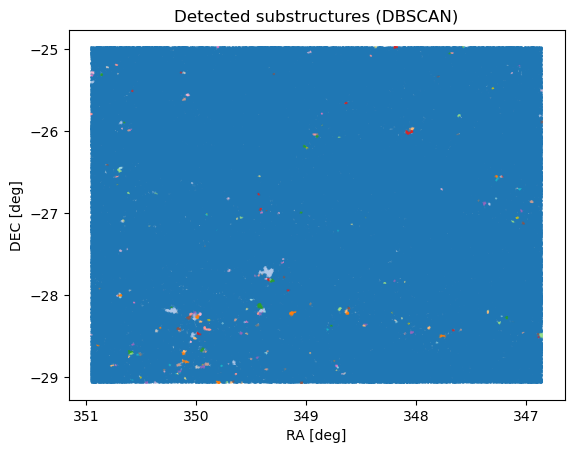

In [200]:
clustering = DBSCAN(eps=0.008, min_samples=10).fit(coords_scaled)
df['cluster_id'] = clustering.labels_

plt.scatter(df['RA'], df['DEC'], c=df['cluster_id'], s=0.1, cmap='tab20', alpha=0.6)
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Detected substructures (DBSCAN)')
plt.gca().invert_xaxis()
plt.show()

In [201]:
df['cluster_id'].nunique()

273

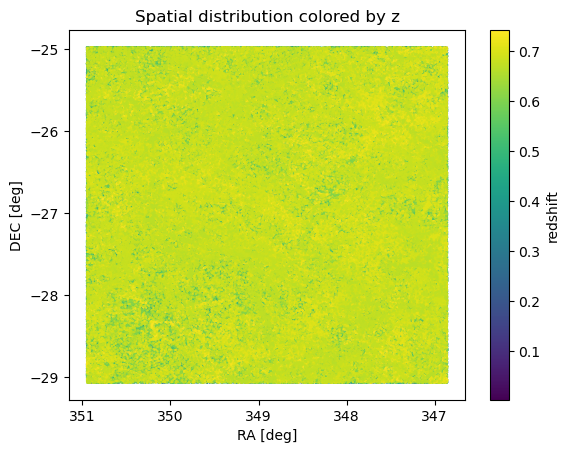

In [151]:
#%matplotlib widget
#%matplotlib inline

plt.scatter(df['RA'], df['DEC'], c=df['redshift_S_1'], s=0.08, cmap='viridis')
plt.colorbar(label='redshift')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Spatial distribution colored by z')
plt.gca().invert_xaxis()
plt.show()

## Single Cluster

In [10]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1269 entries, 0 to 1268
Data columns (total 62 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   x                1269 non-null   float64
 1   x0               1269 non-null   float64
 2   y                1269 non-null   float64
 3   y0               1269 non-null   float64
 4   z                1269 non-null   float64
 5   z0               1269 non-null   float64
 6   Dist_Mpc         1269 non-null   float64
 7   D_projected_deg  1269 non-null   float64
 8   D_projected_Mpc  1269 non-null   float64
 9   True_Members     1269 non-null   float64
 10  Mvir             1269 non-null   float64
 11  icl              1269 non-null   float64
 12  id               1269 non-null   int64  
 13  obs_sfr          1269 non-null   float64
 14  obs_sm           1269 non-null   float64
 15  obs_uv           1269 non-null   float64
 16  sfr              1269 non-null   float64
 17  sm            

In [118]:
data2.iloc[:, :20].describe()

,x,x0,y,y0,z,z0,Dist_Mpc,D_projected_deg,D_projected_Mpc,True_Members,Mvir,icl,id,obs_sfr,obs_sm,obs_uv,sfr,sm,upid,A_UV
count,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.0,1.269000e+03,1.269000e+03,1.269000e+03,1269.000000,1.269000e+03,1269.000000,1269.000000,1.269000e+03,1.269000e+03,1269.000000
mean,-213.023902,1.162621,42.157454,0.147418,110.866397,-0.454244,4.167552,0.734222,3.062893,1.0,8.331689e+11,3.100397e+09,2.676862e+15,0.302787,9.652586e+09,-12.373202,0.269055,9.649952e+09,1.325653e+14,0.071510
std,2.859244,2.859244,2.920850,2.920850,2.256575,2.256575,2.448998,0.509385,2.124960,0.0,1.687853e+13,3.556374e+10,6.317128e+15,0.836996,3.980902e+10,6.323810,0.758104,4.120591e+10,1.234253e+14,0.099232
min,-222.527344,-8.340820,34.388546,-7.621490,104.414085,-6.906555,0.000000,0.000000,0.000000,1.0,7.044877e+09,-8.449937e+08,2.473902e+14,0.000011,7.716093e+07,-20.257343,0.000009,1.011553e+08,-1.000000e+00,0.000000
25%,-214.954102,-0.767578,40.186596,-1.823441,109.315269,-2.005371,2.058080,0.319103,1.331178,1.0,1.929000e+10,3.247448e-02,2.473902e+14,0.015860,2.802895e+08,-16.403854,0.014097,2.741596e+08,-1.000000e+00,0.006195
50%,-213.418945,0.767578,41.955399,-0.054638,110.905670,-0.414970,3.827527,0.616597,2.572207,1.0,4.022000e+10,3.456039e+06,2.473902e+14,0.052922,1.067219e+09,-14.984870,0.046972,1.033744e+09,2.473902e+14,0.039348
75%,-210.673096,3.513428,44.031590,2.021553,112.012703,0.692062,6.518153,1.066746,4.450057,1.0,9.385000e+10,4.220339e+07,2.473902e+14,0.177830,5.518861e+09,-11.775849,0.163836,5.499277e+09,2.473902e+14,0.089458
max,-206.524902,7.661621,49.687634,7.677597,118.683052,7.362411,8.535698,2.125332,8.866076,1.0,5.635000e+14,1.075268e+12,3.424739e+16,13.625200,1.145347e+12,0.000000,13.556625,1.209145e+12,2.473902e+14,0.873407


In [119]:
data2.iloc[:,20:40].describe()

,Mpeak,Vmax_Mpeak,desc_id,lvmp,vmax,vx,vy,vz,RA,DEC,g_lat,g_lon,ecl_lat,ecl_lon,redshift_R,redshift_S_1,dL,nH,ebv,redshift_S_2
count,1.269000e+03,1269.000000,1.269000e+03,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1.269000e+03,1.269000e+03,1269.000000,1269.000000
mean,1.136820e+12,118.100268,2.722568e+15,2.024473,91.056136,-709.694537,-351.798718,515.921825,348.805634,-27.043529,-68.613037,27.606838,-20.388095,338.761178,0.055828,0.058463,7.944386e+26,1.092922e+20,0.036456,0.058463
std,1.712894e+13,80.330615,6.448441e+15,0.179692,68.236515,686.215852,702.044795,680.783731,0.777147,0.430218,0.698010,1.146497,0.519466,0.669868,0.000726,0.002248,1.073716e+25,1.091620e+19,0.011238,0.002248
min,1.537000e+10,57.860001,2.473902e+14,1.762378,30.410000,-2820.469971,-2479.679932,-1938.140015,346.923492,-28.503925,-70.495370,23.575388,-22.001952,336.799983,0.054224,0.050209,7.707392e+26,8.847431e+19,0.021267,0.050209
25%,5.167000e+10,78.269997,2.473902e+14,1.893595,62.230000,-1157.229980,-843.549988,88.589996,348.311035,-27.300144,-69.114205,27.003778,-20.719775,338.348083,0.055263,0.057092,7.860769e+26,1.029509e+20,0.029201,0.057092
50%,9.385000e+10,96.290001,2.473902e+14,1.983581,74.432198,-724.780029,-360.690002,526.280029,348.918762,-27.042301,-68.714213,27.646459,-20.434912,338.869917,0.055938,0.058456,7.960624e+26,1.084306e+20,0.031962,0.058456
75%,2.113000e+11,125.709999,2.473902e+14,2.099370,98.016670,-248.270004,117.529999,994.070007,349.359619,-26.792686,-68.156324,28.271229,-20.123821,339.238427,0.056282,0.059857,8.011577e+26,1.133866e+20,0.040428,0.059857
max,5.635000e+14,1339.660034,3.424739e+16,3.126995,1339.660034,1635.069946,2019.949951,2814.919922,350.899689,-25.133110,-66.895093,32.872211,-18.628072,340.514766,0.057892,0.065746,8.250015e+26,2.210421e+20,0.086418,0.065746


In [120]:
data2.iloc[:,40:].describe()

,log10_sm,log10_sfr,K_mag_abs,u_mag,g_mag,r_mag,i_mag,z_mag,j_mag,h_mag,...,distance_match,ID_glist,subs_labels_0,subs_probs_0,subs_cents_x_0,subs_cents_y_0,subs_cents_z_0,subs_meds_x_0,subs_meds_y_0,subs_meds_z_0
count,1269.000000,1269.000000,1269.000000,1265.000000,1269.000000,1269.000000,1268.000000,1269.000000,1269.000000,1267.000000,...,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000,1269.000000
mean,9.145848,-1.327401,-18.838098,20.733608,19.441957,18.874698,18.607841,18.455238,18.258128,18.045973,...,0.000735,35350.105595,1103.000788,0.390555,-95.749636,18.423096,49.086070,-95.751216,18.426167,49.085356
std,0.826842,0.947845,1.834192,1.621226,1.622837,1.688699,1.755873,1.749504,1.860290,1.866502,...,0.001120,6800.379506,1227.571348,0.450333,105.318115,21.675589,55.683185,105.319698,21.679970,55.682176
min,7.887397,-4.958957,-25.345374,14.591106,13.784091,13.131610,12.987632,12.444778,11.995824,11.823842,...,0.000014,26169.000000,-1.000000,0.000000,-223.264376,-1.000000,-1.000000,-223.354004,-1.000000,-1.000000
25%,8.447607,-1.799689,-20.170661,19.607837,18.299904,17.684395,17.381436,17.224458,16.949274,16.707788,...,0.000317,29538.000000,-1.000000,0.000000,-212.766758,-1.000000,-1.000000,-212.666260,-1.000000,-1.000000
50%,9.028254,-1.276365,-18.590489,20.855911,19.573351,19.040807,18.798982,18.664802,18.463917,18.258122,...,0.000522,35788.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
75%,9.741850,-0.749994,-17.267549,21.853437,20.748468,20.335954,20.076128,19.978865,19.851660,19.559866,...,0.000890,39076.000000,2476.000000,0.932590,-1.000000,41.968889,111.031550,-1.000000,42.010036,111.024948
max,12.058937,1.134343,-15.822477,29.732227,24.019809,22.746330,32.095274,21.739413,21.959643,24.558271,...,0.024865,52900.000000,2506.000000,1.000000,-1.000000,48.426989,117.513585,-1.000000,48.571156,117.421844


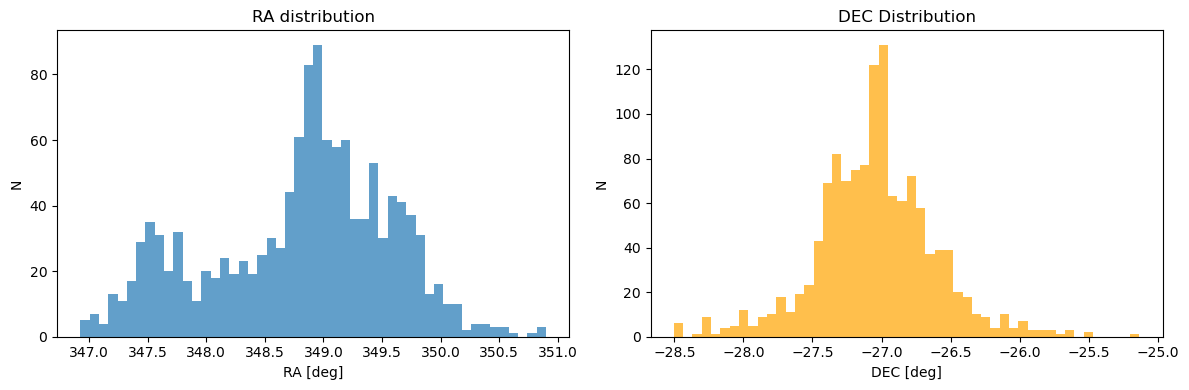

In [153]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(data2['RA'], bins=50, alpha=0.7)
axs[0].set_title('RA')
axs[0].set_xlabel('RA [deg]')
axs[0].set_ylabel('N')

axs[1].hist(data2['DEC'], bins=50, alpha=0.7, color='orange')
axs[1].set_title('DEC')
axs[1].set_xlabel('DEC [deg]')
axs[1].set_ylabel('N')
plt.tight_layout()
plt.show()

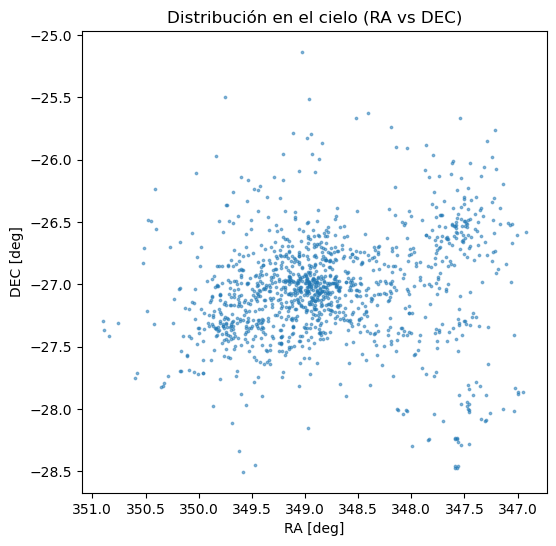

In [122]:
plt.figure(figsize=(6,6))
plt.scatter(data2['RA'], data2['DEC'], s=3, alpha=0.5)
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Sky distribution')
plt.gca().invert_xaxis()
plt.show()

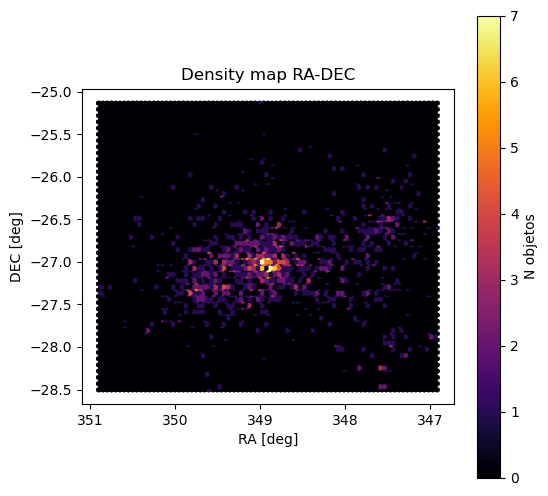

In [187]:
plt.figure(figsize=(6,6))
plt.hexbin(data2['RA'], data2['DEC'], gridsize=80, cmap='inferno')
plt.colorbar(label='N objetos')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Density map RA-DEC')
plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()
plt.show()

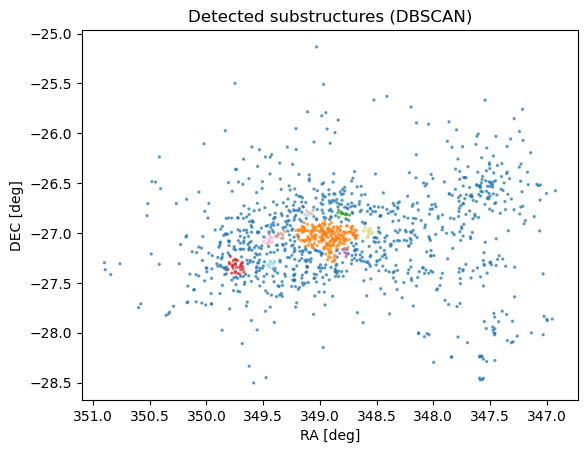

In [202]:
#pequeño test dbscan, no funciona bien con todo el dataset 

coords = np.vstack([data2['RA'], data2['DEC']]).T
dbscan = DBSCAN(eps=0.05, min_samples=10).fit(coords)
data2['cluster_id'] = dbscan.labels_

plt.scatter(data2['RA'], data2['DEC'], c=data2['cluster_id'], s=2, cmap='tab20', alpha=0.6)
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Detected substructures (DBSCAN)')
plt.gca().invert_xaxis()
plt.show()

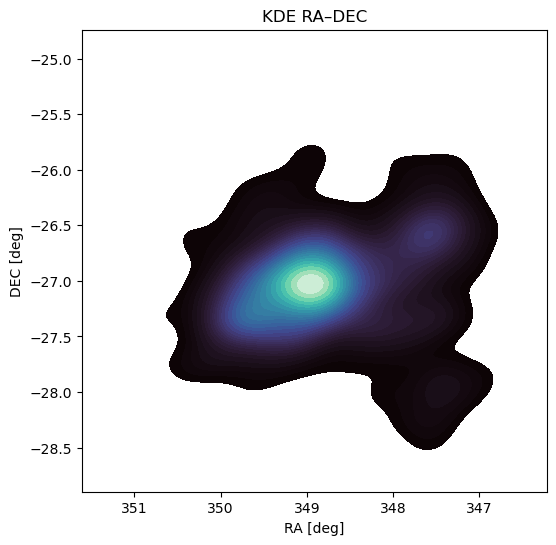

In [8]:
plt.figure(figsize=(6,6))
sns.kdeplot(x=data2['RA'], y=data2['DEC'], fill=True, cmap="mako", levels=30, thresh=0.05)
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('KDE RA–DEC')
plt.gca().invert_xaxis()
plt.show()

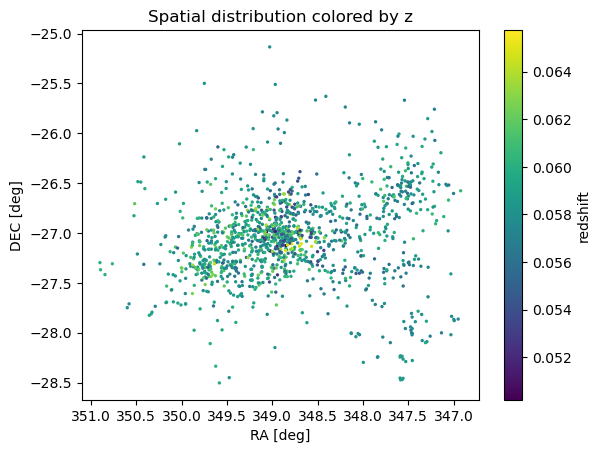

In [179]:
plt.scatter(data2['RA'], data2['DEC'], c=data2['redshift_S_1'], s=2, cmap='viridis')
plt.colorbar(label='redshift')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title('Spatial distribution colored by z')
plt.gca().invert_xaxis()
plt.show()